# Could I have forecast the November rush?

The earlier revenue analysis showed that order volume was rising, but a historical increase is not proof it could have been forecast. I wanted to test whether simple rules could anticipate **observed sold units** in the weeks they had not yet seen. This notebook uses only the published aggregate outputs; the source CSV is not redistributed.

## 1. Avoid using information from the future

I rebuilt weekly units only after repairing the mixed-format dates. The first and last partial weeks were excluded. The full weeks run from 6 Dec 2010 through 4 Dec 2011. One week in Dec 2010 has no observed transactions, which I keep as **zero observed sales**, not proof that consumers wanted nothing. The November test period is held out during model choice.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd().parent if Path.cwd().name=='notebooks' else Path.cwd()
R=ROOT/'results'
s=pd.read_csv(R/'forecast_weekly_history.csv', parse_dates=['WeekStart'])
sel=pd.read_csv(R/'forecast_model_selection.csv')
checks=pd.read_csv(R/'forecast_evaluation.csv')
test=pd.read_csv(R/'forecast_holdout_weeks.csv', parse_dates=['WeekStart'])
summary=json.loads((R/'forecast_summary.json').read_text())
print('Complete weeks:',len(s),'| Selected product codes:',', '.join(summary['sku_list']))
display(sel)

Complete weeks: 52 | Selected product codes: 85123A, 22423, 47566, 84879, 85099B


,Series,Product,Method,ValidationWAPE
0,All products,All product units,eight_week_damped_trend,19.65
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,four_week_mean,40.80
2,22423,REGENCY CAKESTAND 3 TIER,eight_week_damped_trend,25.18
3,47566,PARTY BUNTING,four_week_mean,31.02
4,84879,ASSORTED COLOUR BIRD ORNAMENT,four_week_mean,30.44
5,85099B,JUMBO BAG RED RETROSPOT,four_week_mean,19.70


## 2. Models that have to earn their complexity

With roughly a year of data, I did not assume a long-term seasonal model or a complex machine-learning algorithm would be defensible. I compared three transparent options: a trailing four-week mean, repeating the last four weeks and a damped eight-week trend. Each model was tested on five non-overlapping four-week validation windows from late May through mid-October, using only history available before each window. I chose the method with the lowest pooled validation WAPE **per series**, before inspecting the final November results.

In [2]:
display(pd.read_csv(R/'forecast_validation_folds.csv').groupby(['Series','Method']).apply(lambda z: round(100*z.AbsoluteError.sum()/z.ActualTotal.sum(),2),include_groups=False).unstack().round(1).rename_axis(index=None))

Method,eight_week_damped_trend,four_week_mean,four_week_repeat
22423,25.2,25.6,28.5
47566,31.7,31.0,37.7
84879,32.8,30.4,38.2
85099B,20.4,19.7,24.1
85123A,43.9,40.8,49.8
All products,19.6,20.4,22.3


## 3. The genuinely unseen part

I held out **7 November–4 December 2011**. The selected aggregate model forecast the four weeks using data available through 6 November. The chart below includes the simple mean baseline for comparison. The important finding is not that the selected model was exceptionally accurate: it improved modestly but still missed a substantial late-autumn rise.

Held-out actual: 429081 | selected forecast: 371695 | selected WAPE: 13.37 | simple WAPE: 15.18


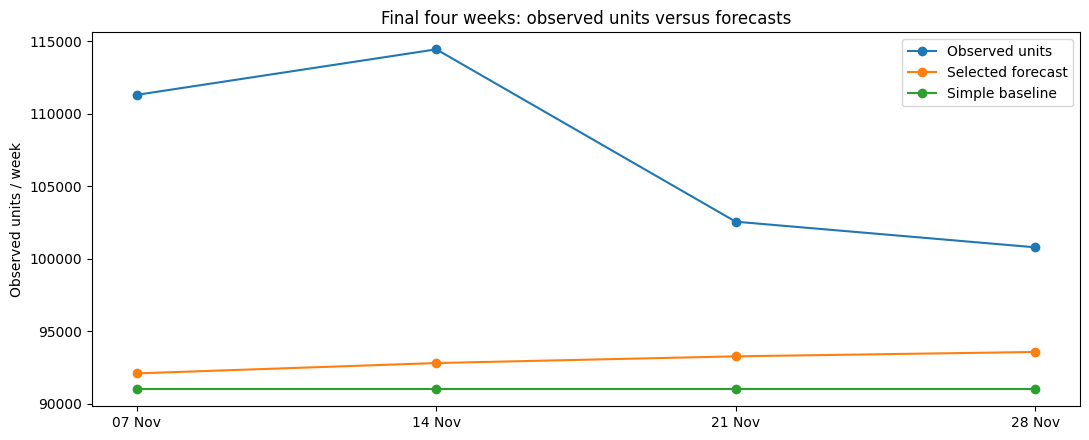

In [3]:
a=test[test.Series=='All products'].sort_values('WeekStart')
e=checks.set_index('Series').loc['All products']
print('Held-out actual:',int(e.ActualTotal),'| selected forecast:',round(e.ForecastTotal),'| selected WAPE:',e.HoldoutWAPE,'| simple WAPE:',e.BaselineHoldoutWAPE)
fig,ax=plt.subplots(figsize=(11,4.5))
labels=a.WeekStart.dt.strftime('%d %b')
ax.plot(labels,a.ActualUnits,marker='o',label='Observed units')
ax.plot(labels,a.ForecastUnits,marker='o',label='Selected forecast')
ax.plot(labels,a.BaselineUnits,marker='o',label='Simple baseline')
ax.set_title('Final four weeks: observed units versus forecasts')
ax.set_ylabel('Observed units / week')
ax.legend();fig.tight_layout();plt.show()

## 4. Did the same approach work for individual products?

Not automatically. Most popular SKUs selected the simple four-week mean during validation. For the cake stand, the selected trend model was **slightly worse** than that baseline on the final holdout. Reporting only the aggregate improvement would hide this result. SKU selection relied on invoice activity *before* the validation periods, so the test did not influence which products were showcased.

In [4]:
display(checks[['Series','Product','SelectedMethod','HoldoutWAPE','BaselineHoldoutWAPE','ActualTotal','ForecastTotal']].round(1))

,Series,Product,SelectedMethod,HoldoutWAPE,BaselineHoldoutWAPE,ActualTotal,ForecastTotal
0,All products,All product units,eight_week_damped_trend,13.4,15.2,429081,371695.3
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,four_week_mean,23.3,23.3,1638,1256.0
2,22423,REGENCY CAKESTAND 3 TIER,eight_week_damped_trend,24.8,24.8,646,721.0
3,47566,PARTY BUNTING,four_week_mean,29.7,29.7,417,302.0
4,84879,ASSORTED COLOUR BIRD ORNAMENT,four_week_mean,18.7,18.7,2512,2042.0
5,85099B,JUMBO BAG RED RETROSPOT,four_week_mean,27.6,27.6,1716,1282.0


## 5. Why I would not deploy this yet

The file contains only positive recorded sales from roughly one year. It does not show out-of-stock items, cancelled transactions, unfilled customer demand, promotions or a second complete annual cycle. Weekly unit sales are only a proxy for demand. A production deployment would need inventory availability, stockout flags, promotion/holiday features and rolling evaluations over multiple years. This is a *historical backtest*, not a forecast of the current retail market.